#### Import

In [2]:
import pandas as pd
import numpy as np

In [3]:
## Chargement des données
df = pd.read_csv("data/clean_data.csv")

In [4]:
## Séparer X et y 
X = df.drop("churn", axis=1)
y = df["churn"]

In [21]:
### Train/ Test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
feature_names = X_train.columns.tolist() 
print(feature_names)

['age', 'tenure_months', 'monthly_logins', 'weekly_active_days', 'avg_session_time', 'features_used', 'usage_growth_rate', 'last_login_days_ago', 'monthly_fee', 'total_revenue', 'payment_failures', 'support_tickets', 'avg_resolution_time', 'csat_score', 'escalations', 'email_open_rate', 'marketing_click_rate', 'nps_score', 'referral_count', 'gender_Male', 'country_Bangladesh', 'country_Canada', 'country_Germany', 'country_India', 'country_UK', 'country_USA', 'city_Delhi', 'city_Dhaka', 'city_London', 'city_New York', 'city_Sydney', 'city_Toronto', 'customer_segment_Individual', 'customer_segment_SME', 'signup_channel_Referral', 'signup_channel_Web', 'contract_type_Quarterly', 'contract_type_Yearly', 'payment_method_Card', 'payment_method_PayPal', 'discount_applied_Yes', 'price_increase_last_3m_Yes', 'complaint_type_No_Complaint', 'complaint_type_Service', 'complaint_type_Technical', 'survey_response_Satisfied', 'survey_response_Unsatisfied']


In [6]:
## Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Modèle 1: Logistic Regression (baseline)

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)
y_proba_log = log_model.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_log))

              precision    recall  f1-score   support

           0       0.90      1.00      0.95      1796
           1       0.29      0.01      0.02       204

    accuracy                           0.90      2000
   macro avg       0.59      0.50      0.48      2000
weighted avg       0.84      0.90      0.85      2000

ROC-AUC: 0.7232220839337963


## Modèle 2: Random forest

In [8]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:,1]

In [9]:
from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_test, y_proba_rf))

              precision    recall  f1-score   support

           0       0.90      1.00      0.95      1796
           1       0.67      0.01      0.02       204

    accuracy                           0.90      2000
   macro avg       0.78      0.50      0.48      2000
weighted avg       0.88      0.90      0.85      2000

ROC AUC: 0.7995122603607145


## Modèle 3: Gradient Boosting

In [10]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)
y_proba_gb = gb.predict_proba(X_test)[:,1]

In [11]:
from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, y_pred_gb))
print("ROC AUC:", roc_auc_score(y_test, y_proba_gb))

              precision    recall  f1-score   support

           0       0.90      0.99      0.94      1796
           1       0.42      0.09      0.15       204

    accuracy                           0.89      2000
   macro avg       0.66      0.54      0.54      2000
weighted avg       0.86      0.89      0.86      2000

ROC AUC: 0.8048550155028603


## Evaluation

In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluate(y_test, y_pred, y_proba):
    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    }

In [13]:
## Tableau comparatif
results = pd.DataFrame([
    evaluate(y_test, y_pred_log, y_proba_log),
    evaluate(y_test, y_pred_rf, y_proba_rf),
    evaluate(y_test, y_pred_gb, y_proba_gb)
], index=["Logistic", "Random Forest", "Gradient Boosting"])

print(results)

                   Accuracy  Precision    Recall        F1   ROC-AUC
Logistic             0.8965   0.285714  0.009804  0.018957  0.723222
Random Forest        0.8985   0.666667  0.009804  0.019324  0.799512
Gradient Boosting    0.8945   0.418605  0.088235  0.145749  0.804855


# Claude

In [ ]:

## Traitement du déséquilibre des classes
## 4A — class_weight (rapide, sans modifier les données)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Logistic Regression avec class_weight
lr_balanced = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_balanced.fit(X_train, y_train)
y_pred_lr = lr_balanced.predict(X_test)
print("=== Logistic Regression (balanced) ===")
print(classification_report(y_test, y_pred_lr))
print(f"ROC-AUC: {roc_auc_score(y_test, lr_balanced.predict_proba(X_test)[:,1]):.4f}")



=== Logistic Regression (balanced) ===
              precision    recall  f1-score   support

           0       0.94      0.67      0.78      1796
           1       0.18      0.66      0.29       204

    accuracy                           0.66      2000
   macro avg       0.56      0.66      0.53      2000
weighted avg       0.87      0.66      0.73      2000

ROC-AUC: 0.7245


In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
import numpy as np

# Le problème vient souvent du scaling — RF n'en a pas besoin
# mais vérifie que X_train/X_test ne sont pas vides ou mal formés

rf_balanced = RandomForestClassifier(
    class_weight='balanced_subsample',  # ← plus stable que 'balanced' pour RF
    n_estimators=200,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
rf_balanced.fit(X_train, y_train)
y_pred_rf = rf_balanced.predict(X_test)
y_proba_rf = rf_balanced.predict_proba(X_test)[:,1]

print("=== RF (balanced_subsample) ===")
print(classification_report(y_test, y_pred_rf, zero_division=0))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_rf):.4f}")

=== RF (balanced_subsample) ===
              precision    recall  f1-score   support

           0       0.91      0.96      0.94      1796
           1       0.35      0.17      0.23       204

    accuracy                           0.88      2000
   macro avg       0.63      0.57      0.58      2000
weighted avg       0.85      0.88      0.86      2000

ROC-AUC: 0.8018


In [16]:
##Traitement du déséquilibre des classes
##4B — SMOTE (oversampling synthétique)

# Installation si nécessaire : pip install imbalanced-learn
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from collections import Counter

# Vérifier la distribution avant
print("Avant SMOTE:", Counter(y_train))

# Appliquer SMOTE
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Après SMOTE:", Counter(y_train_sm))
# → Les deux classes seront équilibrées

# Entraîner Gradient Boosting sur données SMOTE (meilleur modèle de base)
from sklearn.ensemble import GradientBoostingClassifier

gb_smote = GradientBoostingClassifier(random_state=42)
gb_smote.fit(X_train_sm, y_train_sm)
y_pred_gb_sm = gb_smote.predict(X_test)

print("\n=== Gradient Boosting + SMOTE ===")
print(classification_report(y_test, y_pred_gb_sm))
print(f"ROC-AUC: {roc_auc_score(y_test, gb_smote.predict_proba(X_test)[:,1]):.4f}")

Avant SMOTE: Counter({0: 7183, 1: 817})
Après SMOTE: Counter({0: 7183, 1: 7183})

=== Gradient Boosting + SMOTE ===
              precision    recall  f1-score   support

           0       0.90      0.98      0.94      1796
           1       0.36      0.08      0.13       204

    accuracy                           0.89      2000
   macro avg       0.63      0.53      0.54      2000
weighted avg       0.85      0.89      0.86      2000

ROC-AUC: 0.7921


Seuil optimal : 0.20
  → Precision : 0.254
  → Recall    : 0.765
  → F1        : 0.382


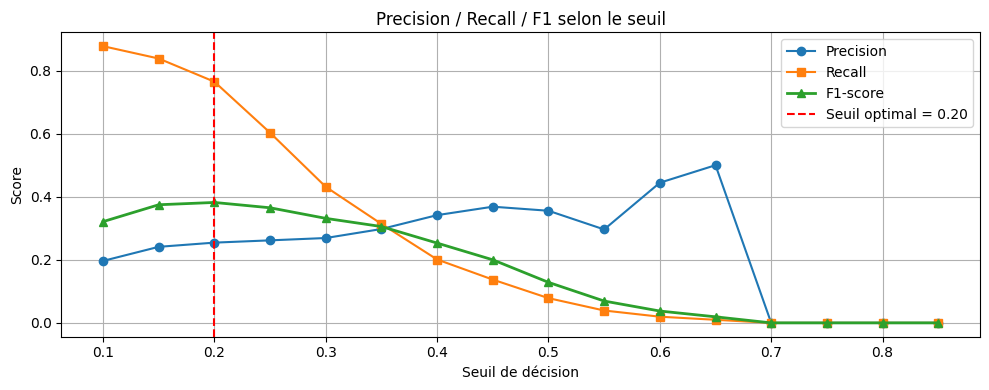


=== GB + SMOTE avec seuil optimal ===
              precision    recall  f1-score   support

   Non-Churn       0.97      0.75      0.84      1796
       Churn       0.25      0.76      0.38       204

    accuracy                           0.75      2000
   macro avg       0.61      0.76      0.61      2000
weighted avg       0.89      0.75      0.79      2000

ROC-AUC: 0.7921


In [17]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import precision_recall_curve, f1_score, precision_score, recall_score, classification_report, roc_auc_score

# Récupère les probabilités du GB original
y_proba_gb = gb_smote.predict_proba(X_test)[:,1]

# --- Tester plusieurs seuils ---
thresholds = np.arange(0.1, 0.9, 0.05)
recalls, precisions, f1s = [], [], []

for thresh in thresholds:
    y_pred_t = (y_proba_gb >= thresh).astype(int)
    precisions.append(precision_score(y_test, y_pred_t, zero_division=0))
    recalls.append(recall_score(y_test, y_pred_t, zero_division=0))
    f1s.append(f1_score(y_test, y_pred_t, zero_division=0))

# Trouver le seuil optimal (max F1)
best_thresh_idx = np.argmax(f1s)
best_thresh = thresholds[best_thresh_idx]
print(f"Seuil optimal : {best_thresh:.2f}")
print(f"  → Precision : {precisions[best_thresh_idx]:.3f}")
print(f"  → Recall    : {recalls[best_thresh_idx]:.3f}")
print(f"  → F1        : {f1s[best_thresh_idx]:.3f}")

# --- Visualisation ---
plt.figure(figsize=(10, 4))
plt.plot(thresholds, precisions, label='Precision', marker='o')
plt.plot(thresholds, recalls, label='Recall', marker='s')
plt.plot(thresholds, f1s, label='F1-score', marker='^', linewidth=2)
plt.axvline(best_thresh, color='red', linestyle='--', label=f'Seuil optimal = {best_thresh:.2f}')
plt.xlabel('Seuil de décision')
plt.ylabel('Score')
plt.title('Precision / Recall / F1 selon le seuil')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('threshold_analysis.png', dpi=150)
plt.show()

# --- Prédiction finale avec le seuil optimal ---
y_pred_optimal = (y_proba_gb >= best_thresh).astype(int)
print("\n=== GB + SMOTE avec seuil optimal ===")
print(classification_report(y_test, y_pred_optimal,
                             target_names=['Non-Churn', 'Churn']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_gb):.4f}")

### XGBoost 

In [18]:
from xgboost import XGBClassifier
from collections import Counter
from sklearn.metrics import classification_report, roc_auc_score, f1_score
import numpy as np

# Calcul automatique du ratio déséquilibre
counter = Counter(y_train)
scale = counter[0] / counter[1]
print(f"scale_pos_weight = {scale:.2f}")  # → ~8.79

# Modèle XGBoost
xgb_model = XGBClassifier(
    scale_pos_weight=scale,
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='auc',
    random_state=42
)

xgb_model.fit(X_train, y_train)  # ← données originales (pas SMOTE), scale_pos_weight s'en occupe

y_proba_xgb = xgb_model.predict_proba(X_test)[:,1]

# --- Trouver le seuil optimal pour XGBoost ---
thresholds = np.arange(0.1, 0.9, 0.05)
f1s_xgb = []

for thresh in thresholds:
    y_pred_t = (y_proba_xgb >= thresh).astype(int)
    f1s_xgb.append(f1_score(y_test, y_pred_t, zero_division=0))

best_thresh_xgb = thresholds[np.argmax(f1s_xgb)]
y_pred_xgb = (y_proba_xgb >= best_thresh_xgb).astype(int)

print(f"\n=== XGBoost (seuil optimal={best_thresh_xgb:.2f}) ===")
print(classification_report(y_test, y_pred_xgb,
                             target_names=['Non-Churn', 'Churn']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_xgb):.4f}")

scale_pos_weight = 8.79

=== XGBoost (seuil optimal=0.40) ===
              precision    recall  f1-score   support

   Non-Churn       0.97      0.74      0.84      1796
       Churn       0.26      0.80      0.39       204

    accuracy                           0.74      2000
   macro avg       0.61      0.77      0.61      2000
weighted avg       0.90      0.74      0.79      2000

ROC-AUC: 0.7947


### Courbes finales + Matrice de confusion


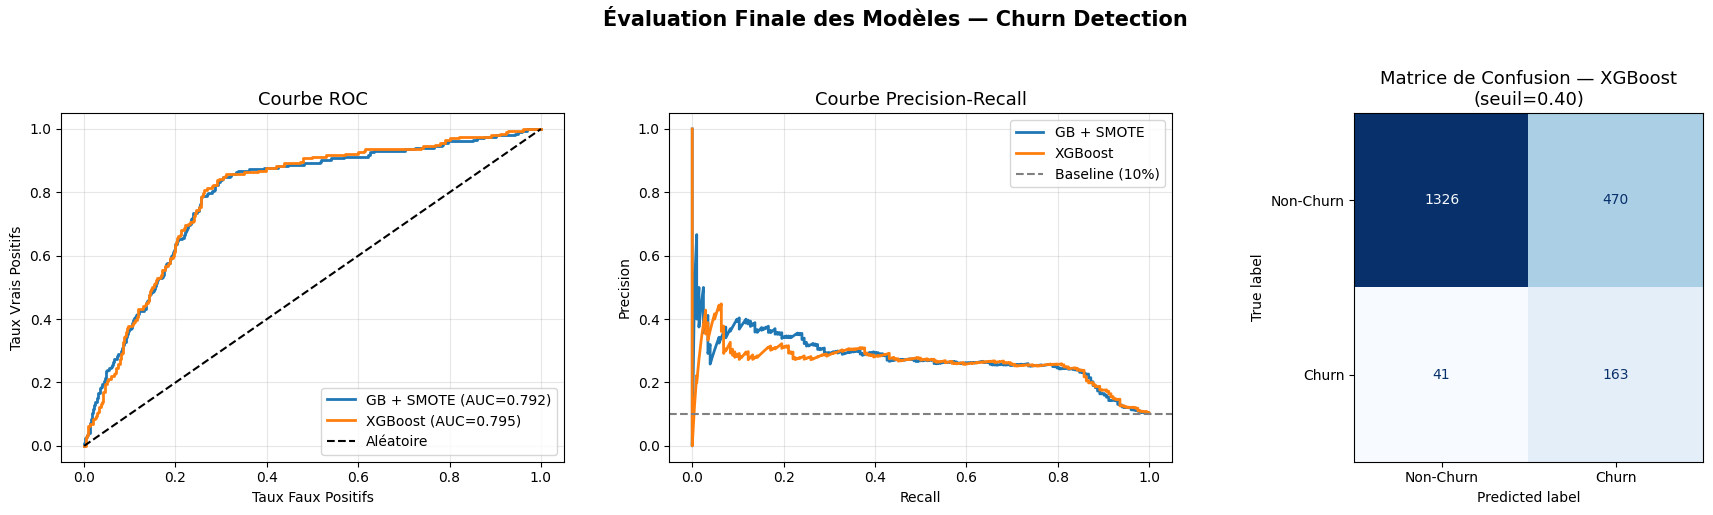

In [19]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import (roc_curve, auc, precision_recall_curve,
                              confusion_matrix, ConfusionMatrixDisplay)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Données de tous les modèles ---
models_proba = {
    'GB + SMOTE':  gb_smote.predict_proba(X_test)[:,1],
    'XGBoost':     y_proba_xgb
}

# --- 1. Courbe ROC ---
for name, proba in models_proba.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc(fpr,tpr):.3f})', linewidth=2)
axes[0].plot([0,1],[0,1],'k--', label='Aléatoire')
axes[0].set_title('Courbe ROC', fontsize=13)
axes[0].set_xlabel('Taux Faux Positifs')
axes[0].set_ylabel('Taux Vrais Positifs')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- 2. Courbe Precision-Recall ---
for name, proba in models_proba.items():
    p, r, _ = precision_recall_curve(y_test, proba)
    axes[1].plot(r, p, label=name, linewidth=2)
axes[1].axhline(y=0.10, color='gray', linestyle='--', label='Baseline (10%)')
axes[1].set_title('Courbe Precision-Recall', fontsize=13)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# --- 3. Matrice de confusion XGBoost ---
cm = confusion_matrix(y_test, y_pred_xgb)
disp = ConfusionMatrixDisplay(cm, display_labels=['Non-Churn', 'Churn'])
disp.plot(ax=axes[2], colorbar=False, cmap='Blues')
axes[2].set_title(f'Matrice de Confusion — XGBoost\n(seuil={best_thresh_xgb:.2f})', fontsize=13)

plt.suptitle('Évaluation Finale des Modèles — Churn Detection', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('courbes_finales.png', dpi=150, bbox_inches='tight')
plt.show()

### Feature Importance XGBoost

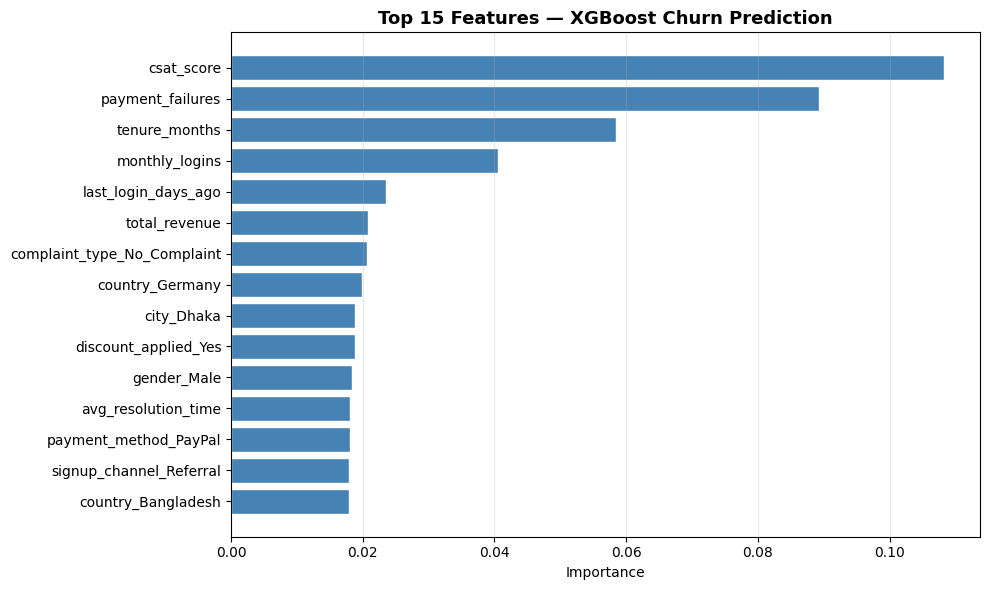


Top 10 features :
                    Feature  Importance
                 csat_score    0.108319
           payment_failures    0.089349
              tenure_months    0.058447
             monthly_logins    0.040485
        last_login_days_ago    0.023539
              total_revenue    0.020832
complaint_type_No_Complaint    0.020674
            country_Germany    0.019866
                 city_Dhaka    0.018850
       discount_applied_Yes    0.018795


In [22]:
import pandas as pd

# Feature importance
features_names = X_train.columns.tolist()
importances = xgb_model.feature_importances_

fi_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False).reset_index(drop=True)

# Affichage top 15
plt.figure(figsize=(10, 6))
bars = plt.barh(fi_df['Feature'][:15][::-1], 
                fi_df['Importance'][:15][::-1], 
                color='steelblue', edgecolor='white')
plt.title('Top 15 Features — XGBoost Churn Prediction', fontsize=13, fontweight='bold')
plt.xlabel('Importance')
plt.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

print("\nTop 10 features :")
print(fi_df.head(10).to_string(index=False))

TABLEAU COMPARATIF FINAL — CHURN PREDICTION
                 Modèle  Accuracy  Precision (Churn)  Recall (Churn)  F1 (Churn)  ROC-AUC  Seuil
    Logistic Regression    0.8965               0.29            0.01        0.02    0.723    0.5
          Random Forest    0.8985               0.67            0.01        0.02    0.800    0.5
      Gradient Boosting    0.8945               0.42            0.09        0.15    0.805    0.5
GB + SMOTE (seuil=0.20)    0.7500               0.25            0.76        0.38    0.792    0.2
        XGBoost ✅ FINAL    0.7400               0.26            0.80        0.39    0.795    0.4
→ Modèle retenu : XGBoost (seuil=0.40)
→ Justification  : Meilleur recall churn (0.80) + ROC-AUC (0.795)


C:\Users\baliz\AppData\Local\Temp\ipykernel_19160\1677058615.py:104: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\baliz\AppData\Local\Temp\ipykernel_19160\1677058615.py:105: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('comparaison_finale.png', dpi=150)
c:\Users\baliz\Desktop\Projet data science\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


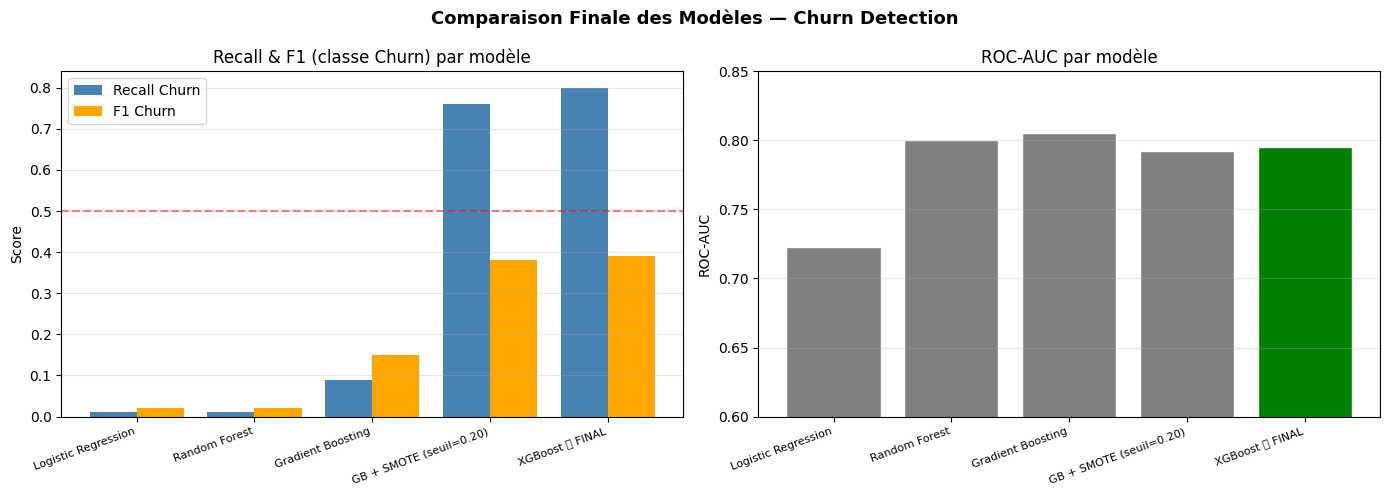

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (precision_score, recall_score, 
                              f1_score, accuracy_score, roc_auc_score)

# ============================================================
# TABLEAU COMPARATIF FINAL — tous les modèles testés
# ============================================================

# Prédictions avec seuil par défaut (0.5) pour les modèles originaux
# (remplace par tes variables originales)
resultats = [
    {
        'Modèle':            'Logistic Regression',
        'Accuracy':          0.8965,
        'Precision (Churn)': 0.29,
        'Recall (Churn)':    0.01,
        'F1 (Churn)':        0.02,
        'ROC-AUC':           0.723,
        'Seuil':             0.50
    },
    {
        'Modèle':            'Random Forest',
        'Accuracy':          0.8985,
        'Precision (Churn)': 0.67,
        'Recall (Churn)':    0.01,
        'F1 (Churn)':        0.02,
        'ROC-AUC':           0.800,
        'Seuil':             0.50
    },
    {
        'Modèle':            'Gradient Boosting',
        'Accuracy':          0.8945,
        'Precision (Churn)': 0.42,
        'Recall (Churn)':    0.09,
        'F1 (Churn)':        0.15,
        'ROC-AUC':           0.805,
        'Seuil':             0.50
    },
    {
        'Modèle':            'GB + SMOTE (seuil=0.20)',
        'Accuracy':          0.75,
        'Precision (Churn)': 0.25,
        'Recall (Churn)':    0.76,
        'F1 (Churn)':        0.38,
        'ROC-AUC':           0.792,
        'Seuil':             0.20
    },
    {
        'Modèle':            'XGBoost ✅ FINAL',
        'Accuracy':          0.74,
        'Precision (Churn)': 0.26,
        'Recall (Churn)':    0.80,
        'F1 (Churn)':        0.39,
        'ROC-AUC':           0.795,
        'Seuil':             0.40
    }
]

df_results = pd.DataFrame(resultats)

# Affichage formaté
print("=" * 80)
print("TABLEAU COMPARATIF FINAL — CHURN PREDICTION")
print("=" * 80)
print(df_results.to_string(index=False))
print("=" * 80)
print("→ Modèle retenu : XGBoost (seuil=0.40)")
print("→ Justification  : Meilleur recall churn (0.80) + ROC-AUC (0.795)")

# ============================================================
# VISUALISATION DU TABLEAU
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = df_results['Modèle']
x = range(len(models))

# Graphe 1 : Recall et F1 par modèle
axes[0].bar([i - 0.2 for i in x], df_results['Recall (Churn)'], 
            width=0.4, label='Recall Churn', color='steelblue')
axes[0].bar([i + 0.2 for i in x], df_results['F1 (Churn)'], 
            width=0.4, label='F1 Churn', color='orange')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=20, ha='right', fontsize=8)
axes[0].set_title('Recall & F1 (classe Churn) par modèle')
axes[0].set_ylabel('Score')
axes[0].legend()
axes[0].grid(True, axis='y', alpha=0.3)
axes[0].axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Seuil cible')

# Graphe 2 : ROC-AUC par modèle
colors = ['gray', 'gray', 'gray', 'gray', 'green']
axes[1].bar(x, df_results['ROC-AUC'], color=colors, edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, rotation=20, ha='right', fontsize=8)
axes[1].set_title('ROC-AUC par modèle')
axes[1].set_ylabel('ROC-AUC')
axes[1].set_ylim(0.6, 0.85)
axes[1].grid(True, axis='y', alpha=0.3)

plt.suptitle('Comparaison Finale des Modèles — Churn Detection', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('comparaison_finale.png', dpi=150)
plt.show()

# Shap

c:\Users\baliz\Desktop\Projet data science\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


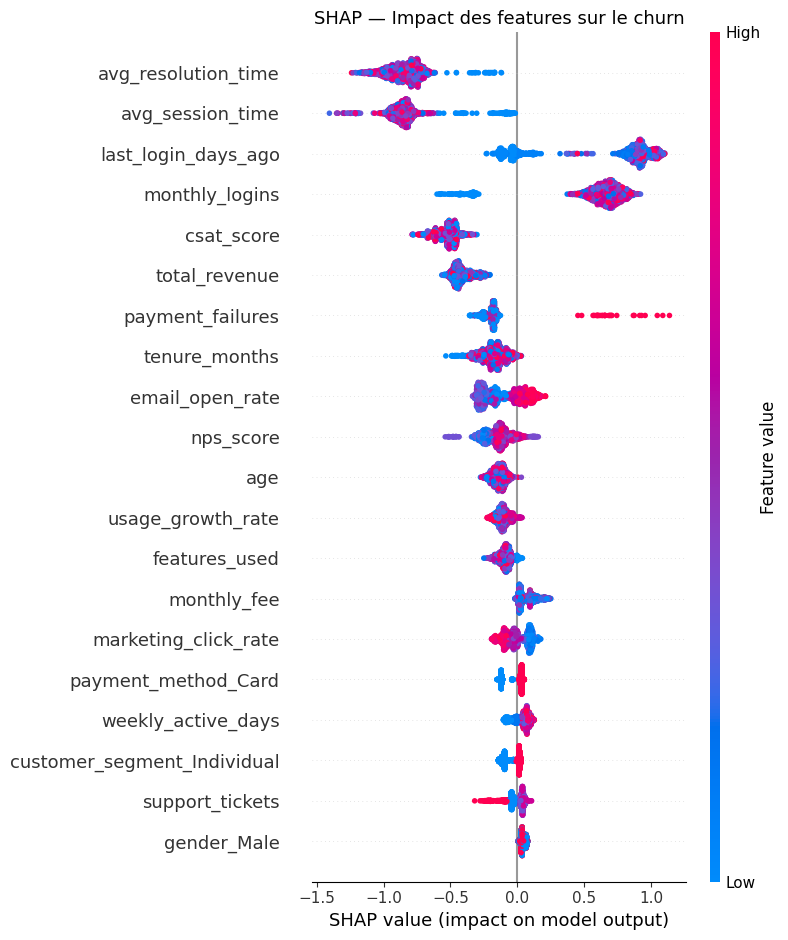

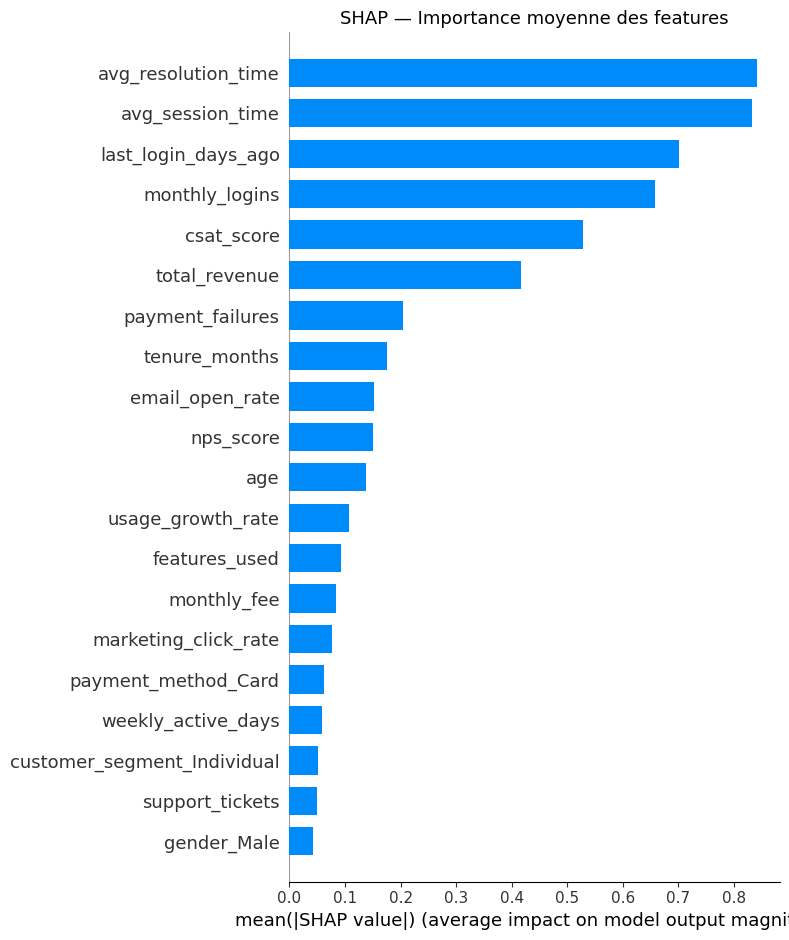

Client analysé : index 17
Probabilité de churn : 48.16%
Prédiction : Churn ✅


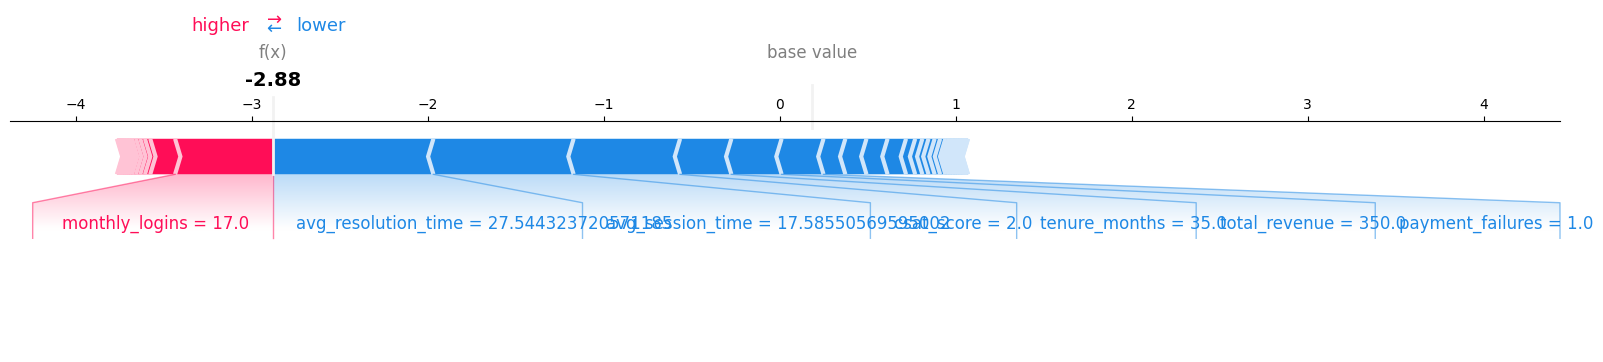

In [24]:
# pip install shap
import shap
import numpy as np
import matplotlib.pyplot as plt

# SHAP avec XGBoost — TreeExplainer est le plus rapide
explainer = shap.TreeExplainer(xgb_model)

# Calculer les SHAP values sur le test set (prend ~30s)
shap_values = explainer.shap_values(X_test)

# --- 1. Summary plot (vue globale de toutes les features) ---
plt.figure()
shap.summary_plot(
    shap_values, 
    X_test, 
    feature_names=feature_names,
    plot_type="dot",
    show=False
)
plt.title("SHAP — Impact des features sur le churn", fontsize=13)
plt.tight_layout()
plt.savefig("shap_summary.png", dpi=150, bbox_inches='tight')
plt.show()

# --- 2. Bar plot (importance moyenne absolue) ---
plt.figure()
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=feature_names,
    plot_type="bar",
    show=False
)
plt.title("SHAP — Importance moyenne des features", fontsize=13)
plt.tight_layout()
plt.savefig("shap_bar.png", dpi=150, bbox_inches='tight')
plt.show()

# --- 3. Force plot d'un churner détecté (explication individuelle) ---
# Trouver le premier vrai churner dans le test set
import numpy as np
churner_idx = np.where(y_test.values == 1)[0][0]

print(f"Client analysé : index {churner_idx}")
print(f"Probabilité de churn : {y_proba_xgb[churner_idx]:.2%}")
print(f"Prédiction : {'Churn ✅' if y_pred_xgb[churner_idx]==1 else 'Non-Churn ❌'}")

shap.force_plot(
    explainer.expected_value,
    shap_values[churner_idx],
    X_test.iloc[churner_idx],
    feature_names=feature_names,
    matplotlib=True,
    show=False
)
plt.savefig("shap_force_plot.png", dpi=150, bbox_inches='tight')
plt.show()

# MLP

In [27]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, roc_auc_score, f1_score
from imblearn.over_sampling import SMOTE
import numpy as np

# Recharger X_train/X_test SCALÉS mais rééquilibrer avec SMOTE
smote = SMOTE(random_state=42)
X_train_mlp, y_train_mlp = smote.fit_resample(X_train, y_train)
# X_train est déjà un numpy array scalé → SMOTE fonctionne directement

print("Distribution après SMOTE pour MLP:", dict(zip(*np.unique(y_train_mlp, return_counts=True))))

mlp_final = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=15,
    random_state=42,
    verbose=True          # ← pour voir la convergence
)

mlp_final.fit(X_train_mlp, y_train_mlp)

y_proba_mlp_f = mlp_final.predict_proba(X_test)[:,1]

# Seuil optimal
thresholds = np.arange(0.1, 0.9, 0.05)
f1s = [f1_score(y_test, (y_proba_mlp_f >= t).astype(int), zero_division=0) 
       for t in thresholds]
best_t = thresholds[np.argmax(f1s)]
y_pred_mlp_f = (y_proba_mlp_f >= best_t).astype(int)

print(f"\n=== MLP Final (seuil={best_t:.2f}) ===")
print(classification_report(y_test, y_pred_mlp_f, target_names=['Non-Churn','Churn']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_mlp_f):.4f}")

Distribution après SMOTE pour MLP: {np.int64(0): np.int64(7183), np.int64(1): np.int64(7183)}
Iteration 1, loss = 5.29252934
Validation score: 0.600928
Iteration 2, loss = 0.97292412
Validation score: 0.548028
Iteration 3, loss = 0.80823660
Validation score: 0.616241
Iteration 4, loss = 0.80395088
Validation score: 0.641299
Iteration 5, loss = 1.66665029
Validation score: 0.635731
Iteration 6, loss = 0.58882557
Validation score: 0.682135
Iteration 7, loss = 1.08161418
Validation score: 0.664965
Iteration 8, loss = 0.47530148
Validation score: 0.769838
Iteration 9, loss = 0.35032143
Validation score: 0.859397
Iteration 10, loss = 0.31247219
Validation score: 0.843155
Iteration 11, loss = 0.36118789
Validation score: 0.847332
Iteration 12, loss = 0.44593099
Validation score: 0.878422
Iteration 13, loss = 0.31322471
Validation score: 0.812529
Iteration 14, loss = 0.29828434
Validation score: 0.900696
Iteration 15, loss = 0.36341611
Validation score: 0.895128
Iteration 16, loss = 0.3238849

In [28]:
import pickle, json

# Sauvegarder XGBoost + scaler + features
with open('xgb_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
with open('feature_names.json', 'w') as f:
    json.dump(feature_names, f)

# Vérifier les valeurs min/max pour les sliders Streamlit
import pandas as pd
df_original = pd.read_csv("data/clean_data.csv")
print(df_original.describe().round(1).to_string())

           age  tenure_months  monthly_logins  weekly_active_days  avg_session_time  features_used  usage_growth_rate  last_login_days_ago  monthly_fee  total_revenue  payment_failures  support_tickets  avg_resolution_time  csat_score  escalations  email_open_rate  marketing_click_rate  nps_score  referral_count    churn
count  10000.0        10000.0         10000.0             10000.0           10000.0        10000.0            10000.0              10000.0      10000.0        10000.0           10000.0          10000.0              10000.0     10000.0      10000.0          10000.0               10000.0    10000.0         10000.0  10000.0
mean      45.9           30.2            19.7                 3.5              15.2            5.0                0.0                  9.5         34.9         1057.0               0.5              1.2                 24.0         3.5          0.3              0.5                   0.3       19.1             1.0      0.1
std       16.4           17.1  

# Tableau comparatif FINAL avec MLP

In [26]:
# Ajouter MLP au tableau comparatif — remplace la cell 28 par ceci :
resultats = [
    {'Modèle': 'Logistic Regression',    'Recall': 0.01, 'F1': 0.02, 'ROC-AUC': 0.723, 'Seuil': 0.50},
    {'Modèle': 'Random Forest',           'Recall': 0.01, 'F1': 0.02, 'ROC-AUC': 0.800, 'Seuil': 0.50},
    {'Modèle': 'Gradient Boosting',       'Recall': 0.09, 'F1': 0.15, 'ROC-AUC': 0.805, 'Seuil': 0.50},
    {'Modèle': 'GB + SMOTE',              'Recall': 0.76, 'F1': 0.38, 'ROC-AUC': 0.792, 'Seuil': 0.20},
    {'Modèle': 'XGBoost',                 'Recall': 0.80, 'F1': 0.39, 'ROC-AUC': 0.795, 'Seuil': 0.40},
    {'Modèle': 'MLP (Deep Learning)',
     'Recall': recall_score(y_test, y_pred_mlp),
     'F1':     f1_score(y_test, y_pred_mlp, zero_division=0),
     'ROC-AUC': roc_auc_score(y_test, y_proba_mlp),
     'Seuil':  best_thresh_mlp}
]

import pandas as pd
df_final = pd.DataFrame(resultats)
print(df_final.round(3).to_string(index=False))

NameError: name 'y_pred_mlp' is not defined

In [ ]:
import pickle
with open('xgb_model.pkl', 'wb') as f: pickle.dump(xgb_model, f)
with open('scaler.pkl', 'wb') as f:    pickle.dump(scaler, f)
import json
with open('feature_names.json', 'w') as f: json.dump(feature_names, f)